# Project Tasks

In the first two assignments, we have learned how to infer part based components (known as mutational signatures) generated by particular mutational processes using Non-negative Matrix Factorization (NMF). By doing this, we are trying to reconstruct the mutation catalog in a given sample with mutational signatures and their contributions.

In this group project, you will use similar mutational profiles and signature activities to predict cancer types but with much larger sample size. 
You should:
* Separate the data into training and test groups within each cancer type.
* Find out which features are informative for the prediction of the cancer type (label). You should try both combining the profiles with activities and using each data type independently.
* Implement different models of your choice for classification of the samples given the input data and evaluate the model performance using test data to avoid overfitting. Explain briefly how does each model that you have used work.
* Report model performance, using standard machine learning metrics such as confusion matrices etc. 
* Compare model performance across methods and across cancer types, are some types easier to predict than others.
* Submit a single Jupyter notebook as the final report and present that during the last assignment session.

# Data

The data include both mutational catalogs from multiple cancers and the predicted activities in the paper ["Alexandrov LB, et al. (2020) The repertoire of mutational signatures in human cancer"](https://www.nature.com/articles/s41586-020-1943-3). The data either are generated from whole human genome (WGS) or only exomes regions (WES). Since the exome region only constitutes about 1% of human genome, the total mutation numbers in these samples are, of course, much smaller. So if you plan to use WGS together with WES data, remember to normalize the profile for each sample to sum up to 1.

Note that, the data is generated from different platforms by different research groups, some of them (e.g. labeled with PCAWG, TCGA) are processed with the same bioinformatics pipeline. Thus, these samples will have less variability related to data processing pipelines.

Cancer types might be labeled under the same tissue, e.g. 'Bone-Benign','Bone-Epith', which can also be combined together or take the one has more samples.

Here is a link to background reading ["Pan-Cancer Analysis of Whole Genomes"](https://www.nature.com/collections/afdejfafdb). Have a look especially at the paper ["A deep learning system accurately classifies primary and metastatic cancers using passenger mutation patterns"](https://www.nature.com/articles/s41467-019-13825-8).

In [283]:
import pandas as pd
import re
import numpy as np

## Mutational catalogs and activities - WGS data

In [372]:
## PCAWG data is performed by the same pipeline
PCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")


PCAWG_wgs_mut_cancers_and_samples = [c.split("::") for c in PCAWG_wgs_mut.columns[2:]]
PCAWG_wgs_mut_data = PCAWG_wgs_mut.values[:,2:].T
PCAWG_wgs_mut_data /= PCAWG_wgs_mut_data.sum(axis=1, keepdims=True)
PCAWG_wgs_mut_data_scaled = StandardScaler().fit_transform(PCAWG_wgs_mut_data)

PCAWG_wgs_mut_cancer_types = np.array([s[0] for s in PCAWG_wgs_mut_cancers_and_samples])
PCAWG_wgs_mut_label_encoder = LabelEncoder().fit(PCAWG_wgs_mut_cancer_types)
PCAWG_wgs_mut_y_int = PCAWG_wgs_mut_label_encoder.transform(PCAWG_wgs_mut_cancer_types)

Accuracy is the cosine similarity of reconstruct catalog to the observed catalog 

In [373]:
## Activities:
PCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
PCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0


In [383]:
# Combined PCAWG dataset (mutation counts + activities)

PCAWG_wgs_combined = PCAWG_wgs_mut.values[:,2:].T
PCAWG_wgs_combined /= PCAWG_wgs_combined.sum(axis=1, keepdims=True) # Normalizing to get relative mutation counts
PCAWG_wgs_combined = np.hstack([np.array([s[1] for s in PCAWG_wgs_mut_cancers_and_samples]).reshape(-1,1), PCAWG_wgs_combined])
PCAWG_wgs_combined = pd.DataFrame(PCAWG_wgs_combined, columns=["Sample Names"] + list(PCAWG_wgs_mut["Mutation type"]))
PCAWG_wgs_combined = pd.merge(PCAWG_wgs_combined, PCAWG_wgs_act, on="Sample Names")

PCAWG_wgs_combined_cancer_types = PCAWG_wgs_combined["Cancer Types"]
PCAWG_wgs_combined = PCAWG_wgs_combined.drop(["Cancer Types"], axis=1)
PCAWG_wgs_combined_data_scaled = StandardScaler().fit_transform(PCAWG_wgs_combined.values[:,1:])
PCAWG_wgs_combined_label_encoder = LabelEncoder().fit(PCAWG_wgs_combined_cancer_types)
PCAWG_wgs_combined_y_int = PCAWG_wgs_combined_label_encoder.transform(PCAWG_wgs_combined_cancer_types)


In [388]:
nonPCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_Other.96.csv")


nonPCAWG_wgs_mut_cancers_and_samples = [c.split("::") for c in nonPCAWG_wgs_mut.columns[2:]]
nonPCAWG_wgs_mut_data = nonPCAWG_wgs_mut.values[:,2:].T
nonPCAWG_wgs_mut_data /= nonPCAWG_wgs_mut_data.sum(axis=1, keepdims=True)
nonPCAWG_wgs_mut_data_scaled = StandardScaler().fit_transform(nonPCAWG_wgs_mut_data)

nonPCAWG_wgs_mut_cancer_types = np.array([s[0] for s in nonPCAWG_wgs_mut_cancers_and_samples])
nonPCAWG_wgs_mut_label_encoder = LabelEncoder().fit(nonPCAWG_wgs_mut_cancer_types)
nonPCAWG_wgs_mut_y_int = nonPCAWG_wgs_mut_label_encoder.transform(nonPCAWG_wgs_mut_cancer_types)

In [376]:
nonPCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_Other.activities.csv")
nonPCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,PD4020a,0.995,208,3006,0,0,365,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ALL,SJBALL011_D,0.905,66,0,0,0,144,0,0,...,0,0,0,0,0,0,0,0,0,0


In [384]:
# Combined nonPCAWG dataset (mutation counts + activities)

nonPCAWG_wgs_mut_cancers_and_samples = [c.split("::") for c in nonPCAWG_wgs_mut.columns[2:]]
nonPCAWG_wgs_combined = nonPCAWG_wgs_mut.values[:,2:].T
nonPCAWG_wgs_combined /= nonPCAWG_wgs_combined.sum(axis=1, keepdims=True) # Normalizing to get relative mutation counts
nonPCAWG_wgs_combined = np.hstack([np.array([s[1] for s in nonPCAWG_wgs_mut_cancers_and_samples]).reshape(-1,1), nonPCAWG_wgs_combined])
nonPCAWG_wgs_combined = pd.DataFrame(nonPCAWG_wgs_combined, columns=["Sample Names"] + list(nonPCAWG_wgs_mut["Mutation type"]))
nonPCAWG_wgs_combined = pd.merge(nonPCAWG_wgs_combined, nonPCAWG_wgs_act, on="Sample Names")

nonPCAWG_wgs_combined_cancer_types = nonPCAWG_wgs_combined["Cancer Types"]
nonPCAWG_wgs_combined = nonPCAWG_wgs_combined.drop(["Cancer Types"], axis=1)
nonPCAWG_wgs_combined_data_scaled = StandardScaler().fit_transform(nonPCAWG_wgs_combined.values[:,1:])
nonPCAWG_wgs_combined_label_encoder = LabelEncoder().fit(nonPCAWG_wgs_combined_cancer_types)
nonPCAWG_wgs_combined_y_int = nonPCAWG_wgs_combined_label_encoder.transform(nonPCAWG_wgs_combined_cancer_types)

## Mutational catalogs - WES data

In [378]:
## Performed by TCGA pipeline
TCGA_wes_mut = pd.read_csv ("./project_data/catalogs/WES/WES_TCGA.96.csv")

TCGA_wes_mut_cancers_and_samples = [c.split("::") for c in TCGA_wes_mut.columns[2:]]
TCGA_wes_mut_data = TCGA_wes_mut.values[:,2:].T
TCGA_wes_mut_data /= TCGA_wes_mut_data.sum(axis=1, keepdims=True)
TCGA_wes_mut_data_scaled = StandardScaler().fit_transform(TCGA_wes_mut_data)

TCGA_wes_mut_cancer_types = np.array([s[0] for s in TCGA_wes_mut_cancers_and_samples])
TCGA_wes_mut_label_encoder = LabelEncoder().fit(TCGA_wes_mut_cancer_types)
TCGA_wes_mut_y_int = TCGA_wes_mut_label_encoder.transform(TCGA_wes_mut_cancer_types)

In [379]:
##Activities
TCGA_wes_act = pd.read_csv("./project_data/activities/WES/WES_TCGA.activities.csv")
TCGA_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,AML,TCGA-AB-2802-03B-01W-0728-08,0.811,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AML,TCGA-AB-2803-03B-01W-0728-08,0.608,4,0,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [380]:
other_wes_mut = pd.read_csv("./project_data/catalogs/WES/WES_Other.96.csv")

other_wes_mut_cancers_and_samples = [c.split("::") for c in other_wes_mut.columns[2:]]
other_wes_mut_data = other_wes_mut.values[:,2:].T
other_wes_mut_data /= other_wes_mut_data.sum(axis=1, keepdims=True)
other_wes_mut_data_scaled = StandardScaler().fit_transform(other_wes_mut_data)

other_wes_mut_cancer_types = np.array([s[0] for s in other_wes_mut_cancers_and_samples])
other_wes_mut_label_encoder = LabelEncoder().fit(other_wes_mut_cancer_types)
other_wes_mut_y_int = other_wes_mut_label_encoder.transform(other_wes_mut_cancer_types)


In [381]:
other_wes_act = pd.read_csv("./project_data/activities/WES/WES_Other.activities.csv")
other_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,TARGET-10-PAIXPH-03A-01D,0.529,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,ALL,TARGET-10-PAKHZT-03A-01R,0.696,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [382]:
# Combined 'other' dataset (mutation counts + activities)

other_wes_mut_cancers_and_samples = [c.split("::") for c in other_wes_mut.columns[2:]]
other_wes_combined = other_wes_mut.values[:,2:].T
other_wes_combined /= other_wes_combined.sum(axis=1, keepdims=True) # Normalizing to get relative mutation counts
other_wes_combined = np.hstack([np.array([s[1] for s in other_wes_mut_cancers_and_samples]).reshape(-1,1), other_wes_combined])
other_wes_combined = pd.DataFrame(other_wes_combined, columns=["Sample Names"] + list(other_wes_mut["Mutation type"]))
other_wes_combined = pd.merge(other_wes_combined, other_wes_act, on="Sample Names")

other_wes_combined_cancer_types = other_wes_combined["Cancer Types"]
other_wes_combined = other_wes_combined.drop(["Cancer Types"], axis=1)
other_wes_combined_data_scaled = StandardScaler().fit_transform(other_wes_combined.values[:,1:])
other_wes_combined_label_encoder = LabelEncoder().fit(other_wes_combined_cancer_types)
other_wes_combined_y_int = other_wes_combined_label_encoder.transform(other_wes_combined_cancer_types)

# neural network attempt

In [418]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import random
import numpy as np
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

### Organizing data sets

In [392]:
data_dict = {}

for name, X, y, label_encoder in [
        ["PCAWG_mut", PCAWG_wgs_mut_data_scaled, PCAWG_wgs_mut_y_int, PCAWG_wgs_mut_label_encoder],
        ["PCAWG_mut_act_combined", PCAWG_wgs_combined_data_scaled, PCAWG_wgs_combined_y_int, PCAWG_wgs_combined_label_encoder],
        ["nonPCAWG_mut", nonPCAWG_wgs_mut_data_scaled, nonPCAWG_wgs_mut_y_int, nonPCAWG_wgs_mut_label_encoder],
        ["nonPCAWG_mut_act_combined", nonPCAWG_wgs_combined_data_scaled, nonPCAWG_wgs_combined_y_int, nonPCAWG_wgs_combined_label_encoder],
        ["TCGA_wes_mut", TCGA_wes_mut_data_scaled, TCGA_wes_mut_y_int, TCGA_wes_mut_label_encoder],
        ["other_wes_mut", other_wes_mut_data_scaled, other_wes_mut_y_int, other_wes_mut_label_encoder],
        ["other_wes_combined", other_wes_combined_data_scaled, other_wes_combined_y_int, other_wes_combined_label_encoder],
    ]:
    data_dict[name] = (X, y, label_encoder)
    

# NN definitions

In [396]:
# Helper class for feed forward nets

class NetMaker(nn.Module):
    def __init__(self,
                 activation=nn.ReLU(),
                 add_dropout=False,
                 drop_rate=.2,
                 add_batchnorm=False):
        super(NetMaker, self).__init__()
        self.activation = activation
        self.add_dropout = add_dropout
        self.drop_rate = drop_rate
        self.add_batchnorm = add_batchnorm

    def forward(self, layer_dims):
        layers = [nn.Linear(in_features=layer_dims[0], out_features=layer_dims[1])]
        
        if self.add_batchnorm:
            layers.append(nn.BatchNorm1d(num_features=layer_dims[1], eps=1e-8))
        layers.append(self.activation)
        if self.add_dropout:
            layers.append(nn.Dropout(self.drop_rate))
        for ind, dim in enumerate(layer_dims[1:-2], start=1):
            layers.append(nn.Linear(in_features=dim, out_features=layer_dims[ind + 1]))
            if self.add_batchnorm:
                layers.append(nn.BatchNorm1d(num_features=layer_dims[ind+1], eps=1e-8))
            layers.append(self.activation)
            if self.add_dropout:
                layers.append(nn.Dropout(self.drop_rate))
        
        layers.append(nn.Linear(in_features=layer_dims[-2], out_features=layer_dims[-1]))
        if self.add_batchnorm:
            layers.append(nn.BatchNorm1d(num_features=layer_dims[-1], eps=1e-8))
        return nn.Sequential(*layers)


In [ ]:
# Classifier NN

class CancerClassifier(nn.Module):
    def __init__(self,
                 input_dim,
                 hidden_dims,
                 n_classes,
                 device="cpu"):
        super().__init__()
        self.device = device
        self.predictor = NetMaker(add_dropout=True)([input_dim] + hidden_dims + [n_classes])

    def predict_logits(self, x):
        logits = self.predictor(x)
        return logits
    
    def predict(self, x):
        probs = torch.softmax(self.predict_logits(x), dim=-1)
        y_hat = probs.argmax(dim=1)
        return y_hat
    
    def fit(self, X, y, n_epochs=1, batch_size=128):
        
        X = torch.Tensor(X).to(self.device)
        y = torch.Tensor(y).to(self.device).long()
        trainX, testX, trainY, testY = train_test_split(X, y, test_size=.1, shuffle=True)
        trainY = trainY.to(self.device)
        testY = testY.to(self.device)
        testX = testX.to(self.device)
        trainX = trainX.to(self.device)
        dataloader = DataLoader(TensorDataset(torch.Tensor(trainX), torch.Tensor(trainY)), batch_size=batch_size, shuffle=True, drop_last=True)
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        criterion = torch.nn.CrossEntropyLoss()

        train_accs = []
        test_accs = []

        for epoch in range(n_epochs):
            epoch_train_accs = []
            for batchX, batchY in dataloader:
                self.train()
                optimizer.zero_grad()
                logits = self.predict_logits(batchX)
                loss = criterion(logits, batchY)
                
                loss.backward()
                optimizer.step()

                preds = self.predict(batchX)
                acc = (preds == batchY).sum() / len(batchX)
                epoch_train_accs.append(acc)
            
            train_accs.append(np.mean(epoch_train_accs))
            self.eval()
            preds = self.predict(testX)
            acc = (preds == testY).sum() / len(testX)
            test_accs.append(acc)
            print(f"Epoch [{epoch+1}] ---- acc: {acc:.3}  ", end="\r")

        fig = plt.figure(figsize=(10,8), dpi=100)
        ax = fig.add_subplot(111)
        ax.plot(train_accs, label="train accuracy")
        ax.plot(test_accs, label="test accuracy")
        ax.legend()
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        plt.show()
            
        return self


In [438]:
# Simple autoencoder

class AutoEncoder(nn.Module):
    def __init__(self,
                 input_dim,
                 hidden_dims,
                 latent_dim,
                 device="cpu"
                 ):
        super().__init__()
        self.device = device
        self.encoder = NetMaker()([input_dim] + hidden_dims + [latent_dim]).to(device)
        self.decoder = NetMaker()([latent_dim] + hidden_dims[::-1] + [input_dim]).to(device)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded
    
    def fit(self, X, y=None, n_epochs=1, batch_size=128, save_epochs=[]):

        X = torch.Tensor(X).to(self.device)

        if y is not None:
            y = torch.Tensor(y).to(self.device)
            trainX, valX, trainY, valY = train_test_split(X, y, test_size=.1, shuffle=True)
            trainY = trainY.to(self.device)
            valY = valY.to(self.device)
            dataloader = DataLoader(TensorDataset(torch.Tensor(trainX), torch.Tensor(trainY)), batch_size=batch_size, shuffle=True, drop_last=True)
            
        else:
            trainX, valX = train_test_split(X, test_size=.05, shuffle=True)
            dataloader = DataLoader(TensorDataset(torch.Tensor(trainX)), batch_size=batch_size, shuffle=True, drop_last=True)


        valX = valX.to(self.device)
        trainX = trainX.to(self.device)
          
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        train_losses = []
        test_losses = []

        for epoch in range(n_epochs):
            self.train()
            epoch_train_losses = []
            for batch in dataloader:
                if y is not None:
                    batchX, batchY = batch
                else:
                    batchX = batch[0]

                optimizer.zero_grad()
                
                encoded, decoded = self(batchX)
                loss = nn.L1Loss()(decoded, batchX)
                epoch_train_losses.append(loss.item())
                loss.backward()
                optimizer.step()
            train_losses.append(np.mean(epoch_train_losses))
            self.eval()
            encoded, decoded = self(valX)
            loss = nn.L1Loss()(decoded, valX)
            test_losses.append(loss.item())
        
            
        fig = plt.figure(figsize=(10,8), dpi=100)
        ax = fig.add_subplot(111)
        ax.plot(train_losses, label="train reconstruction error")
        ax.plot(test_losses, label="test reconstruction error")
        ax.legend()
        ax.set_xlabel("Epoch")
        ax.set_ylabel("L1 error")
        plt.show()
        

        return self


# Looping through datasets and fitting classifiers

########### dataset: PCAWG_mut ###########


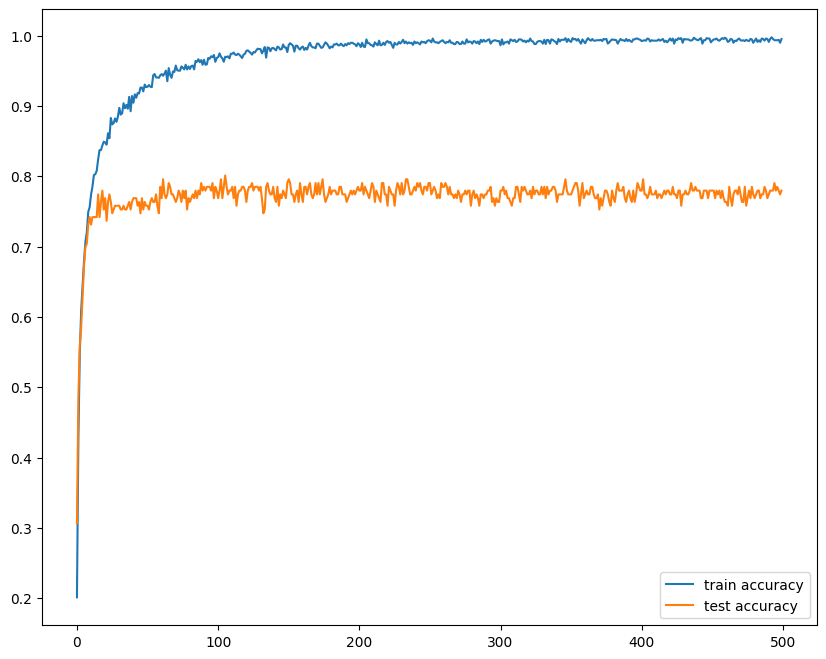

Validation set accuracy: 0.756


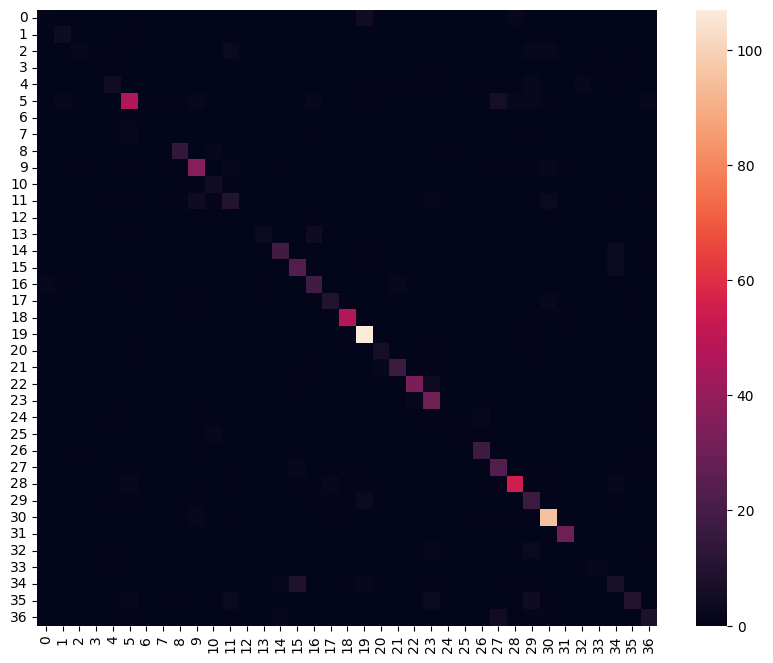

########### dataset: PCAWG_mut_act_combined ###########


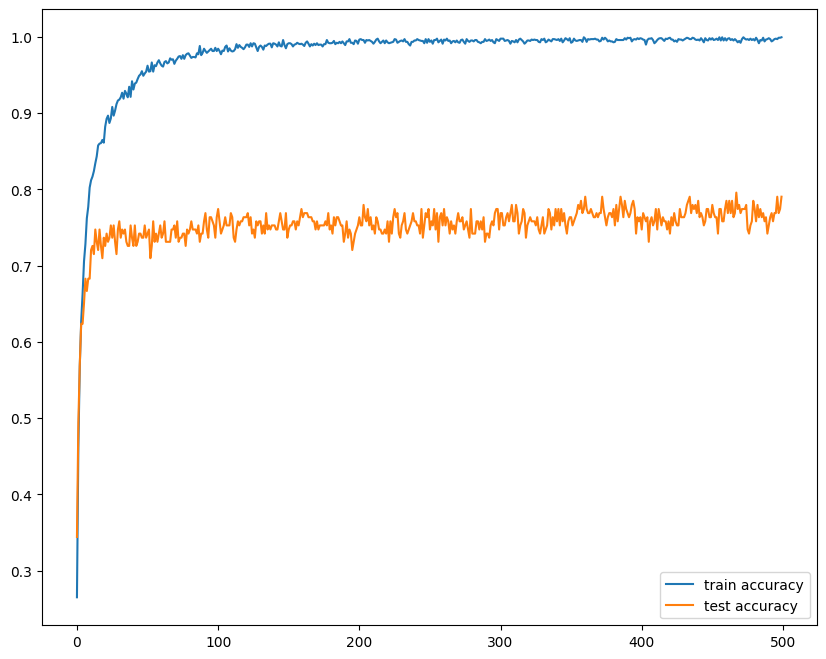

Validation set accuracy: 0.783


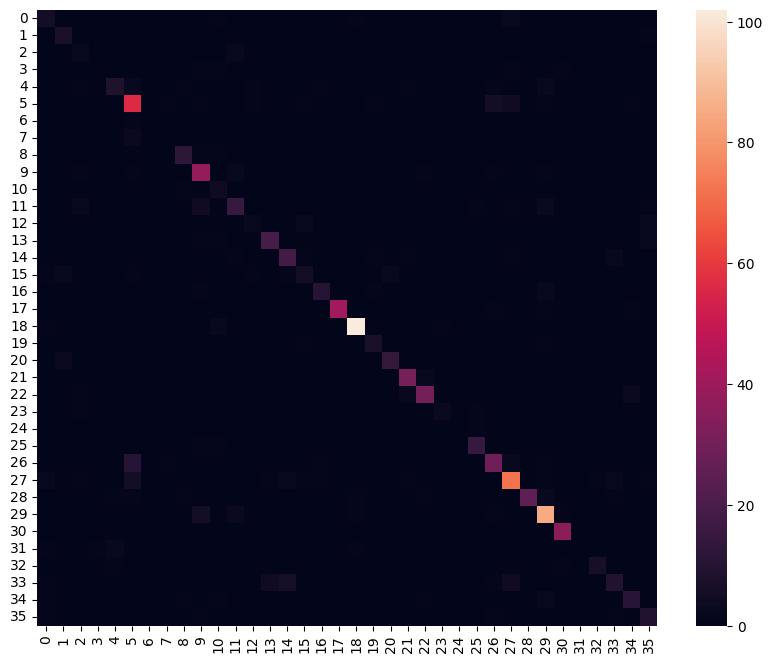

########### dataset: nonPCAWG_mut ###########


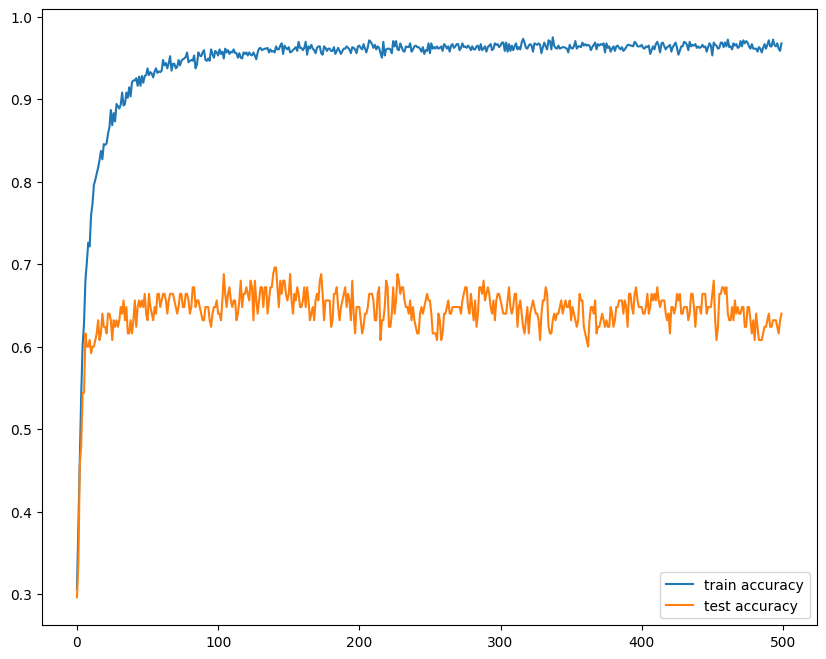

Validation set accuracy: 0.698


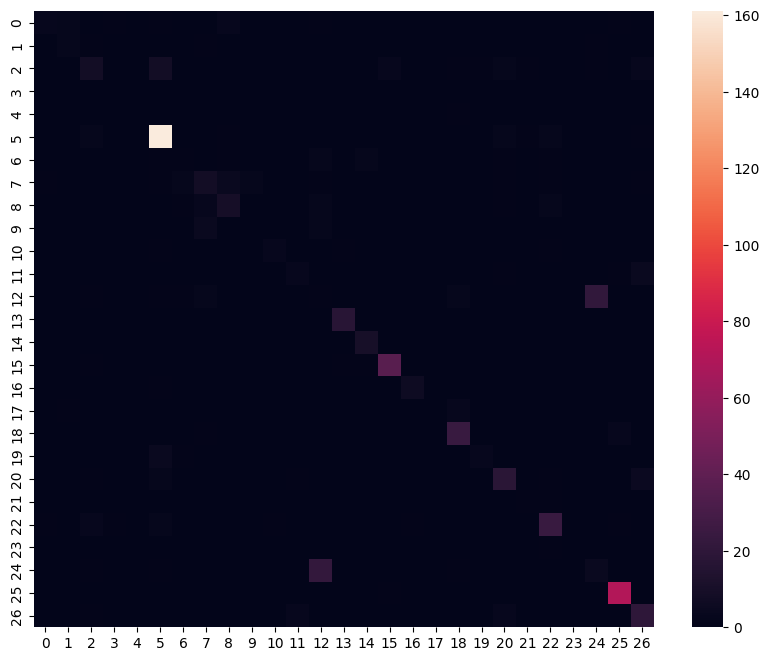

########### dataset: nonPCAWG_mut_act_combined ###########


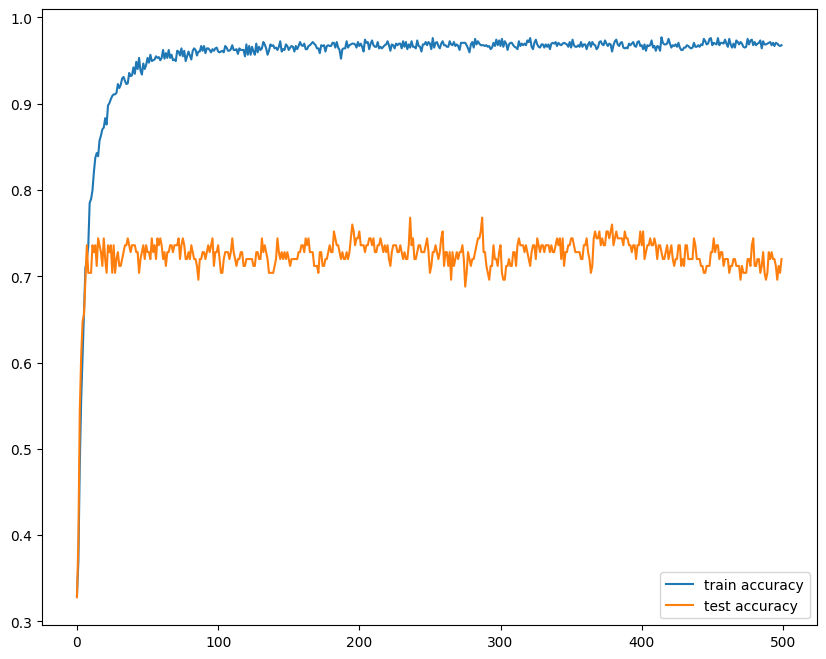

Validation set accuracy: 0.733


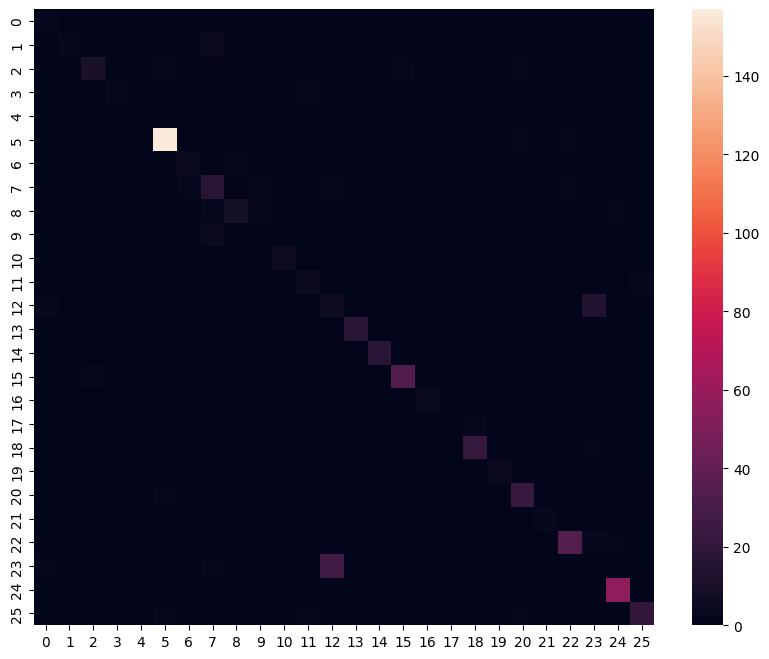

########### dataset: TCGA_wes_mut ###########


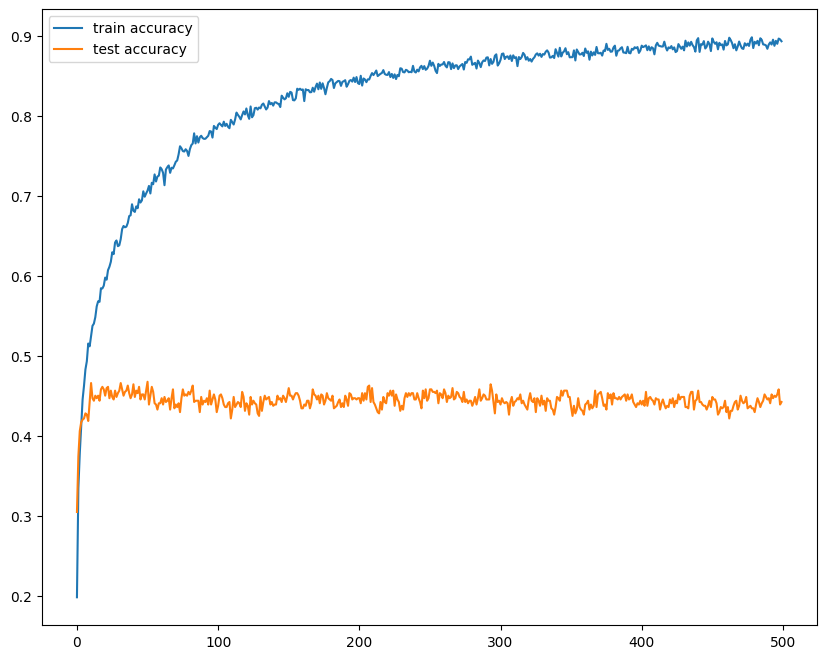

Validation set accuracy: 0.426


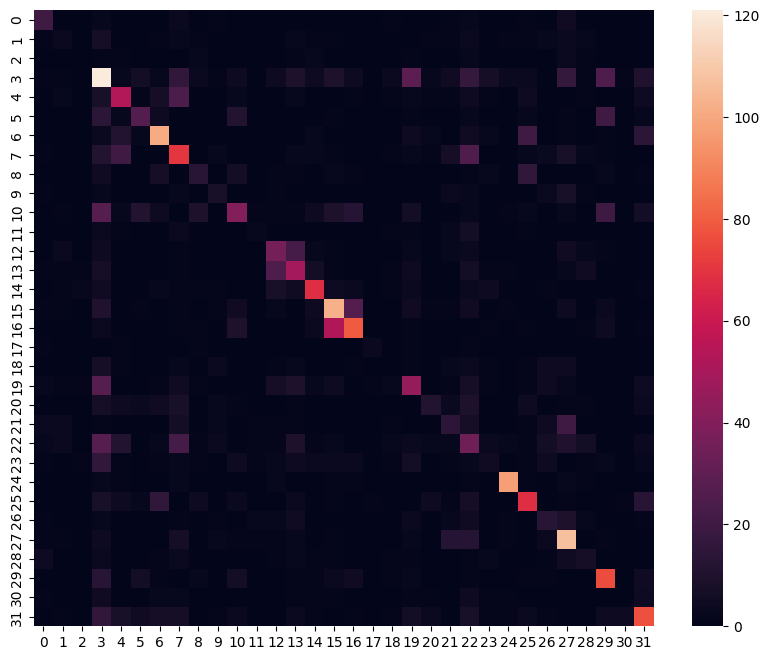

########### dataset: other_wes_mut ###########


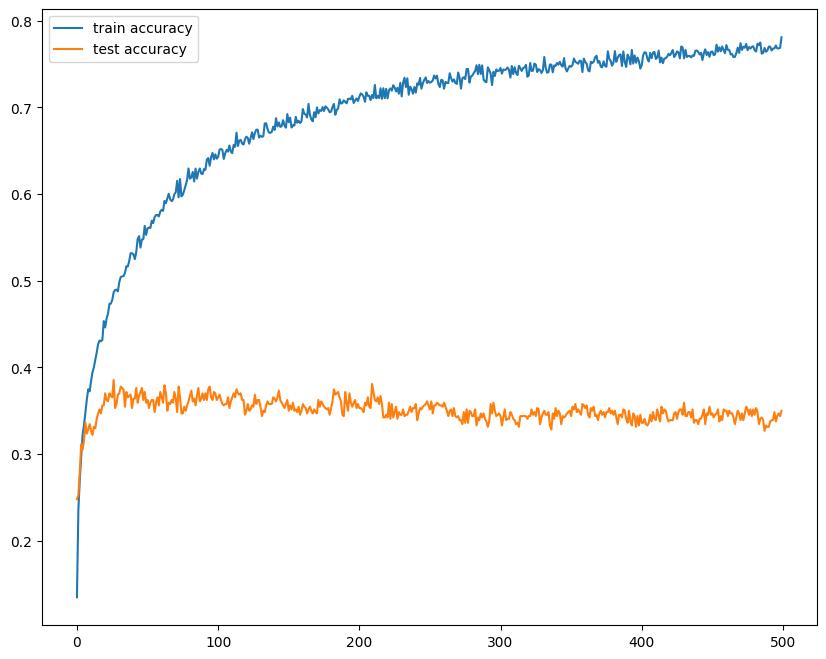

Validation set accuracy: 0.326


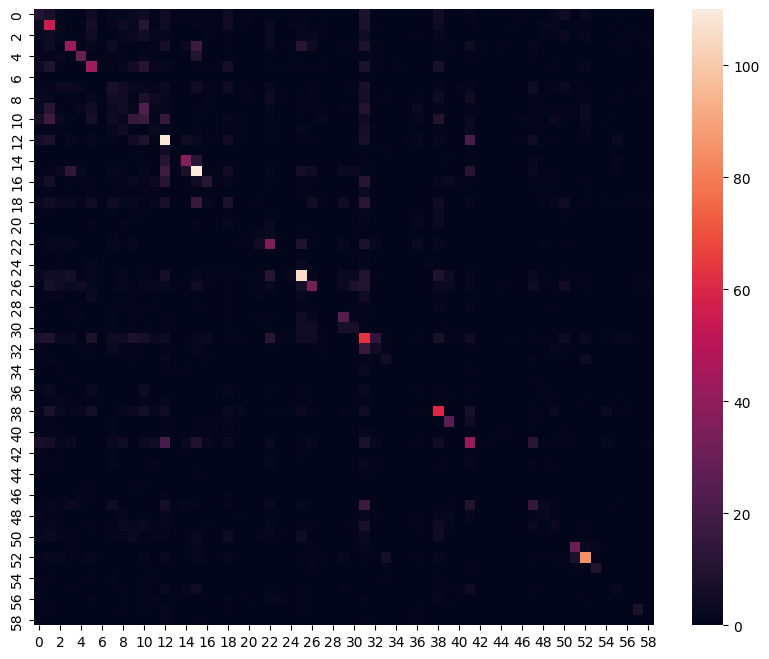

########### dataset: other_wes_combined ###########


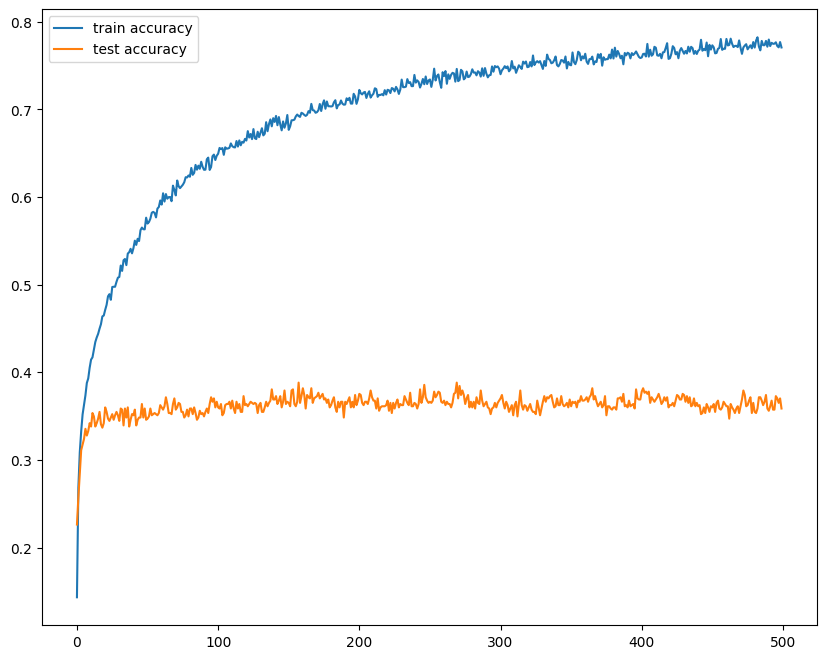

Validation set accuracy: 0.365


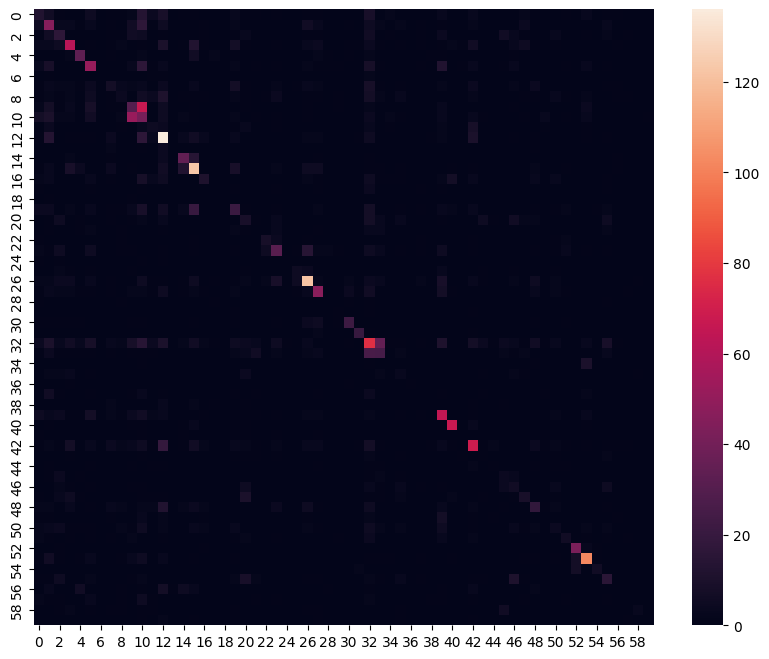

In [427]:
classifier_hidden_dims = [128, 128]

for name, (X, y, encoder) in data_dict.items():
    print(f"########### dataset: {name} ###########")
    
    trainX, valX, trainY, valY = train_test_split(X, y, test_size=1/3)
    name_classifier = CancerClassifier(input_dim=X.shape[1], hidden_dims=classifier_hidden_dims, n_classes=len(set(y))).fit(trainX,
                                                                                                                            trainY,
                                                                                                                            n_epochs=500,
                                                                                                                            batch_size=64)
    
    val_preds = name_classifier.predict(x=torch.Tensor(valX).to(name_classifier.device))
    validation_accuracy = (val_preds == valY).sum() / len(val_preds)
    
    print(f"Validation set accuracy: {validation_accuracy:.3}")
    fig = plt.figure(figsize=(10,8), dpi=100)
    sns.heatmap(confusion_matrix(valY, val_preds), annot=False)
    plt.show()



# Classifier analysis

- The classfier architecture is pretty basic: I did no fancy stuff
    - Dropout is applied to combat overfitting
    - hidden dimensions are 128 for 2 hidden layers
        - Did not test other setups
- The best results are obtained on the *PCAWG_mut_act_combined* dataset (mutation fractions + activity values)
    - Accuracy over the validation set is around 78% (I think RF outperforms this?)
    - Surely better performance is possbile, but I do not have the time / energy to go further

# Best classification results with *PCAWG_mut_act_combined* - fitting an autoencoder on this data

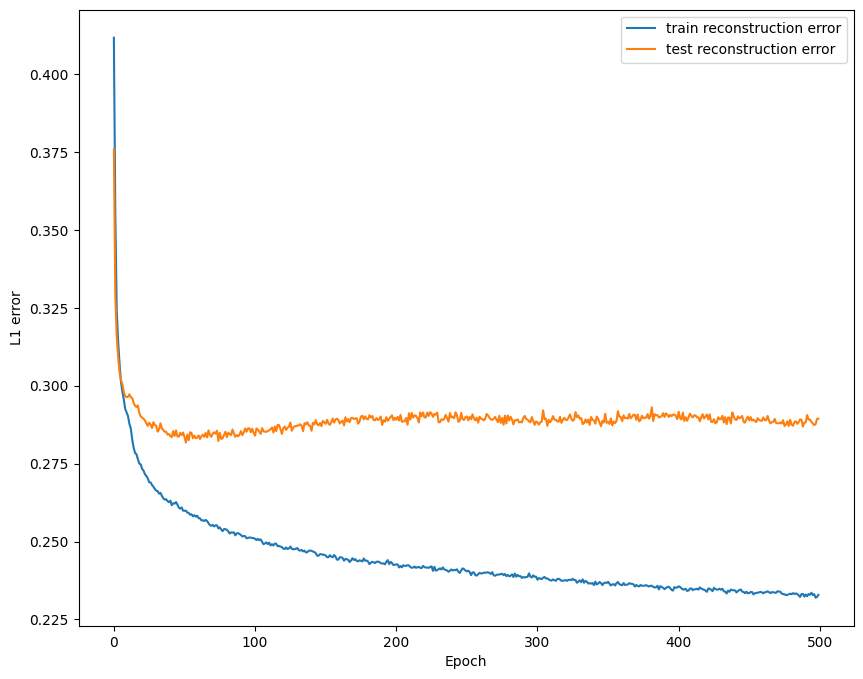

In [450]:
X, y, encoder = data_dict["PCAWG_mut_act_combined"]
ae_hidden_dims = [128,128]

AE = AutoEncoder(input_dim=X.shape[1], hidden_dims=ae_hidden_dims, latent_dim=2).fit(X,
                                                                                     y=None,
                                                                                     n_epochs=500,
                                                                                     batch_size=64)

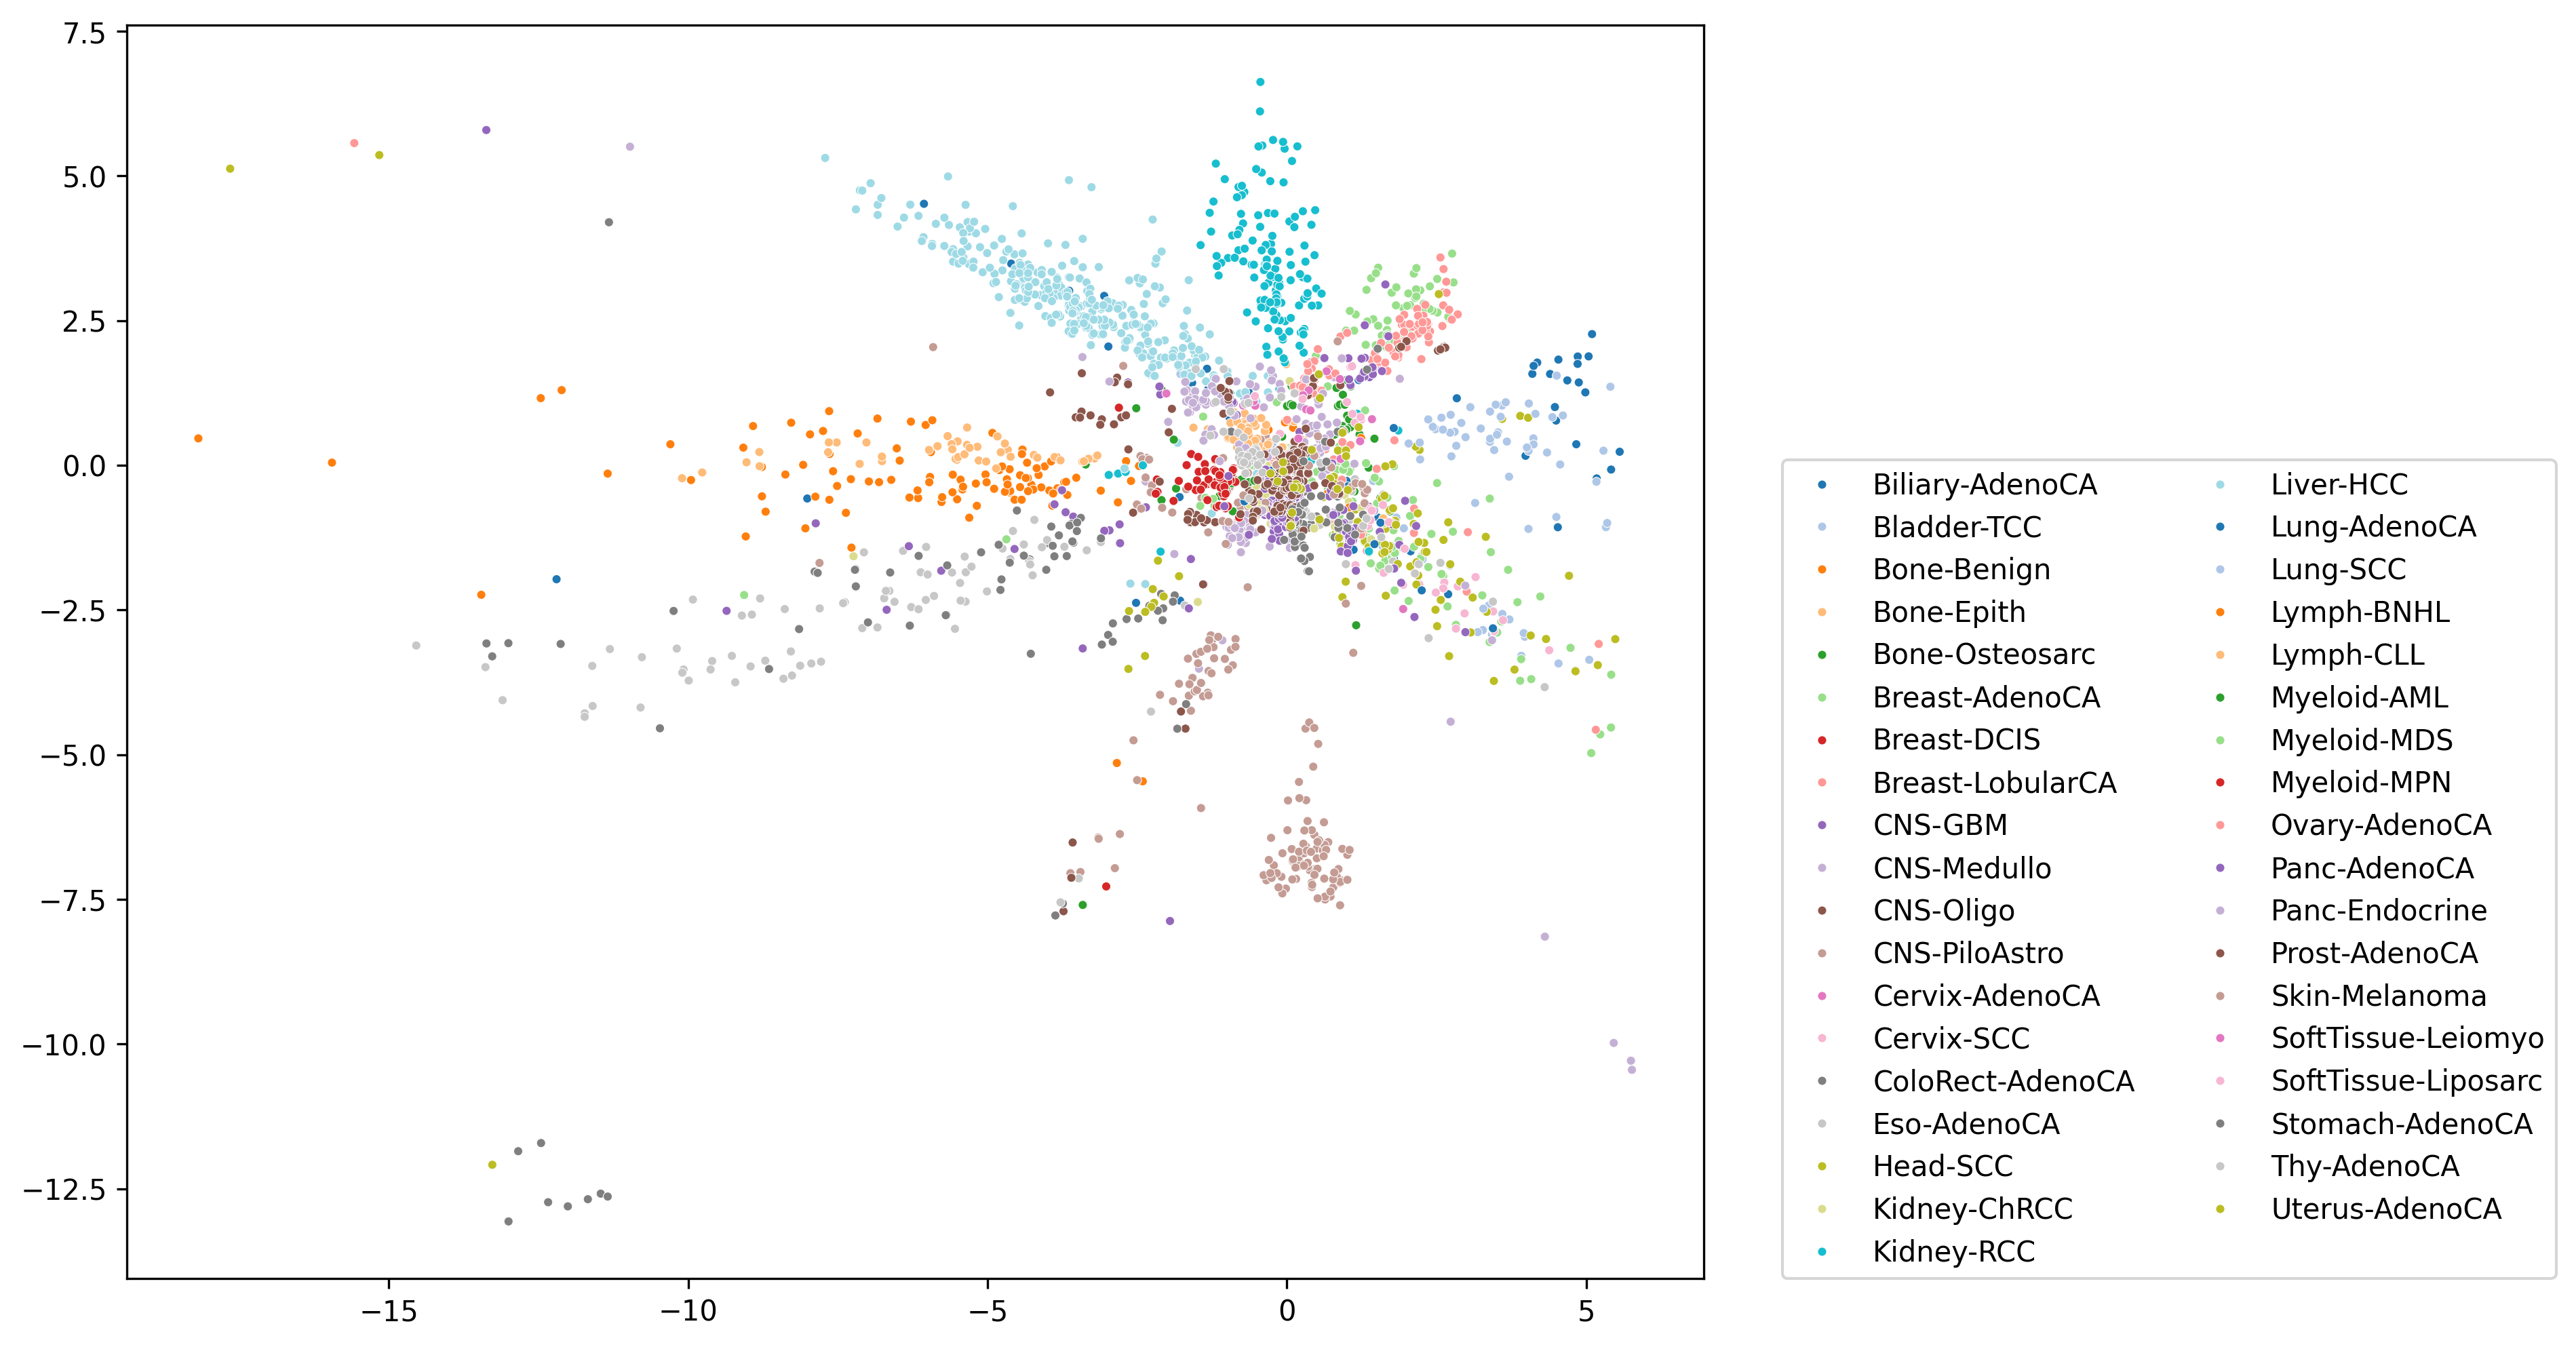

In [451]:
encoded, decoded = AE(torch.Tensor(X))
encoded = encoded.detach().numpy()

fig = plt.figure(figsize=(10,8), dpi=300)
sns.scatterplot(x=encoded[:,0], y=encoded[:,1], s=10, hue=encoder.inverse_transform(y), palette="tab20")
plt.legend(loc=(1.05,0), ncol=2)

# Autoencoder notes

- I only tried with 2 128 dimensional hidden layers
    - Could try more?
- The losses converge nicely
- Different cancer types definitely separate in the AE latent space
    - I do not have the energy to inverstigate further